# Stock Price Trend Prediction: LSTM vs Random Forest vs Linear Regression

**Goal:** predict the next trading day's closing price from the previous 30 days and compare three models.

**Method in brief**
1. Download historical prices with `yfinance`
2. Build 30-day input windows, target = next day's close
3. Split **by time** (first 80% train, last 20% test) so the model never sees the future
4. Fit the scaler on training data only
5. Compare Naive baseline, Linear Regression, Random Forest and LSTM using RMSE, MAE and directional accuracy

In [1]:
# Run this cell first in Google Colab (yfinance and TensorFlow are usually preinstalled except yfinance)
!pip install yfinance -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

np.random.seed(42)

TICKER = "RELIANCE.NS"      # change to any ticker, e.g. "TCS.NS", "AAPL"
START, END = "2015-01-01", "2026-09-30"
WINDOW = 30                 # days of history used as input
TRAIN_FRAC = 0.8

## 1. Load data

(2904,) 2015-01-01 to 2026-09-29


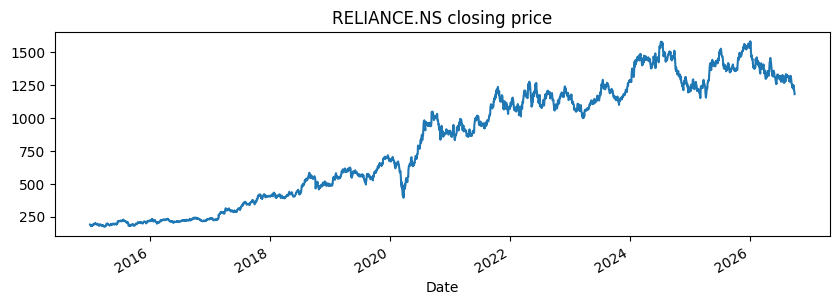

In [3]:
df = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
if isinstance(df.columns, pd.MultiIndex):      # newer yfinance versions
    df.columns = df.columns.get_level_values(0)
close = df["Close"].dropna()
print(close.shape, close.index.min().date(), "to", close.index.max().date())
close.plot(figsize=(10, 3), title=f"{TICKER} closing price"); plt.show()

## 2. Split by time and scale (scaler fitted on the training part only)

In [4]:
values = close.values.reshape(-1, 1)
split_idx = int(len(values) * TRAIN_FRAC)

scaler = MinMaxScaler()
scaler.fit(values[:split_idx])                  # no information from the test period
scaled = scaler.transform(values)

X, y = [], []
for i in range(WINDOW, len(scaled)):
    X.append(scaled[i - WINDOW:i, 0])
    y.append(scaled[i, 0])
X, y = np.array(X), np.array(y)

# window i predicts day (i + WINDOW); put it in train only if that day is in the training period
target_idx = np.arange(WINDOW, len(scaled))
train_mask = target_idx < split_idx
X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[~train_mask], y[~train_mask]
print("train windows:", X_train.shape, " test windows:", X_test.shape)

train windows: (2293, 30)  test windows: (581, 30)


## 3. Models

In [5]:
def to_price(a):
    return scaler.inverse_transform(np.array(a).reshape(-1, 1)).ravel()

actual = to_price(y_test)
prev_close = to_price(X_test[:, -1])            # yesterday's close for each test sample

preds = {}
preds["Naive (yesterday's close)"] = prev_close

lr = LinearRegression().fit(X_train, y_train)
preds["Linear Regression"] = to_price(lr.predict(X_test))

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1).fit(X_train, y_train)
preds["Random Forest"] = to_price(rf.predict(X_test))

In [6]:
# LSTM (requires TensorFlow; available by default in Google Colab)
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
Xtr = X_train.reshape(-1, WINDOW, 1)
Xte = X_test.reshape(-1, WINDOW, 1)

model = Sequential([
    LSTM(64, input_shape=(WINDOW, 1)),
    Dropout(0.2),
    Dense(1),
])
model.compile(optimizer="adam", loss="mse")
model.fit(Xtr, y_train, epochs=50, batch_size=32, validation_split=0.1,
          callbacks=[EarlyStopping(patience=5, restore_best_weights=True)], verbose=0)
preds["LSTM"] = to_price(model.predict(Xte, verbose=0))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## 4. Evaluation
Directional accuracy = how often the model correctly predicts whether the price goes up or down versus the previous day.

In [7]:
rows = []
for name, p in preds.items():
    rmse = np.sqrt(mean_squared_error(actual, p))
    mae = mean_absolute_error(actual, p)
    direction = np.nan if name.startswith("Naive") else np.mean(np.sign(p - prev_close) == np.sign(actual - prev_close)) * 100   # naive predicts "no change", so direction is not defined
    rows.append({"Model": name, "RMSE": round(rmse, 2), "MAE": round(mae, 2), "Directional accuracy (%)": round(direction, 1)})
results = pd.DataFrame(rows).set_index("Model")
results.to_csv("results.csv")
results

,RMSE,MAE,Directional accuracy (%)
Model,,,
Naive (yesterday's close),18.30,13.42,NaN
Linear Regression,18.58,13.75,44.2
Random Forest,43.04,33.17,51.6
LSTM,34.80,27.21,51.8


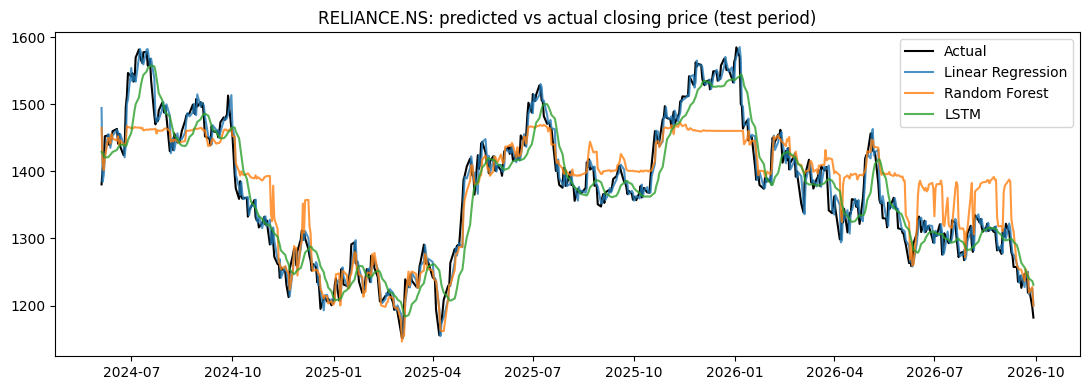

In [8]:
test_dates = close.index[split_idx:][-len(actual):]
plt.figure(figsize=(11, 4))
plt.plot(test_dates, actual, label="Actual", color="black", linewidth=1.5)
for name in ["Linear Regression", "Random Forest", "LSTM"]:
    plt.plot(test_dates, preds[name], label=name, alpha=0.8)
plt.title(f"{TICKER}: predicted vs actual closing price (test period)")
plt.legend(); plt.tight_layout()
plt.savefig("predictions.png", dpi=150); plt.show()

## 5. Findings

The naive baseline (yesterday's close) achieved the lowest error (RMSE 18.30), and Linear Regression came very close (RMSE 18.58, MAE 13.75). Random Forest (RMSE 43.04) and LSTM (RMSE 34.80) performed noticeably worse than the baseline. Directional accuracy for all models was between 44.2% and 51.8%, close to a coin flip, so none of the models predicted up and down moves reliably. This analysis used only one stock and past closing prices, so the results may not generalize to other stocks.